In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [1]:
import pandas as pd

sheet_id = "1i5iFNYoLfwOCQ5oxVaZDFZt9Xjlb6-LO6oOmcLmmRdg"

url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv"

df = pd.read_csv(url)

In [8]:
# df = pd.read_csv('coffeeshoprevenue.csv')
# df.head()

In [9]:
df.isnull().sum()

Number_of_Customers_Per_Day    0
Average_Order_Value            0
Operating_Hours_Per_Day        0
Number_of_Employees            0
Marketing_Spend_Per_Day        0
Location_Foot_Traffic          0
Daily_Revenue                  0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#Class Imbalance

df['Daily_Revenue'].value_counts()
df['Daily_Revenue'].value_counts(normalize=True)

df['Daily_Revenue'].value_counts().plot(kind='bar')

<Axes: xlabel='Daily_Revenue'>

<Axes: xlabel='Daily_Revenue'>

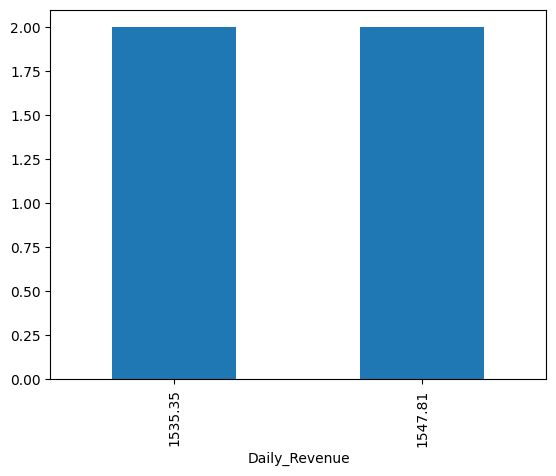

In [ ]:
#Resampling

from sklearn.utils import resample

majority_class = df['Daily_Revenue'].value_counts().idxmax()
minority_class = df['Daily_Revenue'].value_counts().idxmin()

df_majority = df[df['Daily_Revenue'] == majority_class]
df_minority = df[df['Daily_Revenue'] == minority_class]

df_minority_upsampled = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=42)

df_upsampled = pd.concat([df_majority, df_minority_upsampled])

df_upsampled['Daily_Revenue'].value_counts().plot(kind='bar')


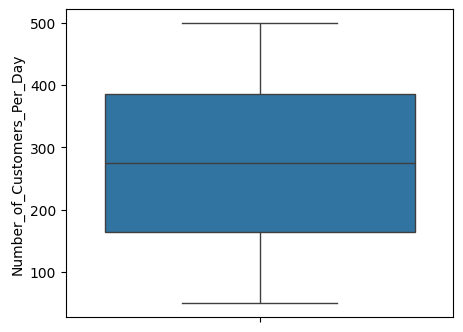

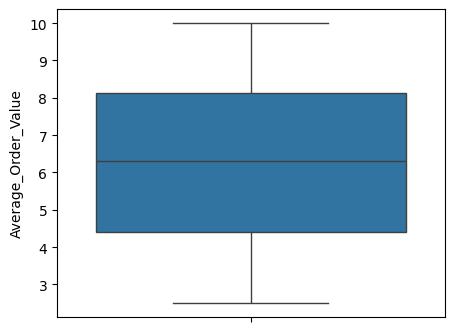

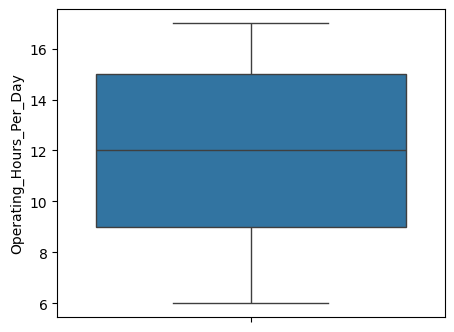

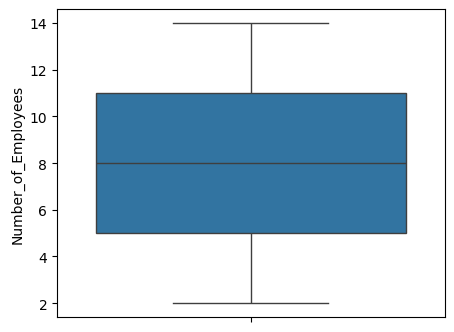

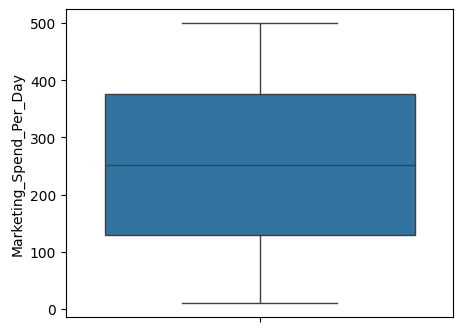

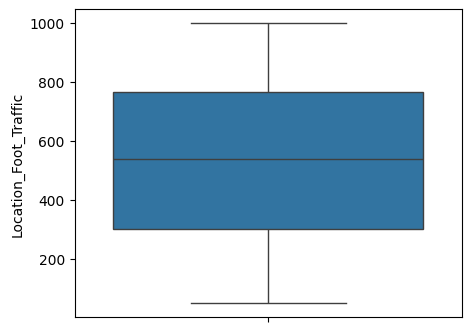

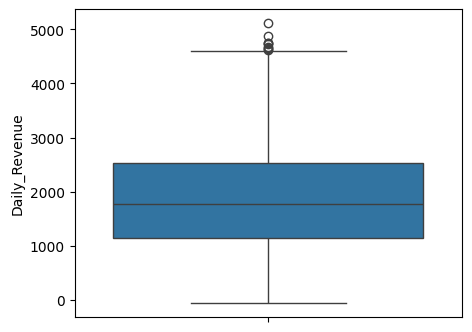

In [ ]:
allcols = df.select_dtypes(include=np.number).columns

for c in allcols:
    plt.figure(figsize=(5, 4))
    sns.boxplot(df[c])
    plt.show()

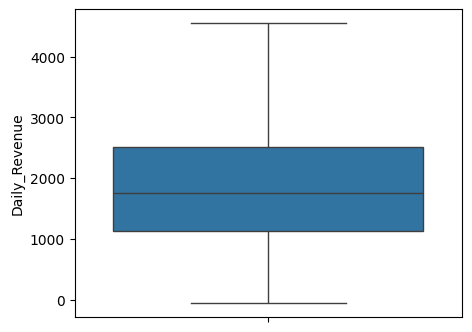

In [ ]:
# Outliers are present in the data. We will handle them using IQR method.

IQR = df['Daily_Revenue'].quantile(0.75) - df['Daily_Revenue'].quantile(0.25)
lower_bound = df['Daily_Revenue'].quantile(0.25) - (1.5 * IQR)
upper_bound = df['Daily_Revenue'].quantile(0.75) + (1.5 * IQR)  
df = df[(df['Daily_Revenue'] >= lower_bound) & (df['Daily_Revenue'] <= upper_bound)]

plt.figure(figsize=(5, 4))
sns.boxplot(df['Daily_Revenue'])
plt.show()
#Ran 2 times to remove outliers. After 2nd time, no outliers are present in the data.

In [ ]:
X = df[allcols.drop('Daily_Revenue')]

Y = df['Daily_Revenue']


In [ ]:
from sklearn.preprocessing import StandardScaler

std = StandardScaler()
X_scaled = std.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
from xgboost import XGBRegressor

from sklearn.metrics import (

    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# Create Model

xgb_model = XGBRegressor(

    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

# Train Model

xgb_model.fit(X_train, Y_train)

# Prediction

xgb_pred = xgb_model.predict(X_test)

# Metrics

print('XGBoost MAE:',
      mean_absolute_error(Y_test, xgb_pred))

print('XGBoost MSE:',
      mean_squared_error(Y_test, xgb_pred))

rmse = np.sqrt(
    
    mean_squared_error(
        Y_test,
        xgb_pred
    )
)

print('XGBoost RMSE:', rmse)

print('XGBoost R2 Score:',
      r2_score(Y_test, xgb_pred))

XGBoost MAE: 190.65015755351462
XGBoost MSE: 53892.62729963808
XGBoost RMSE: 232.14785654758495
XGBoost R2 Score: 0.9403997187913223


In [ ]:
import joblib as jb

jb.dump(xgb_model,'xgboost_model.pkl')

['xgboost_model.pkl']